In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.ensemble import AdaBoostClassifier

from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

In [3]:
#load the data
data=pd.read_csv(r"C:\Users\Amit kumar\Downloads\diabetes.csv")
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
#check information about data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
for i in data:
    print("####--------------------------------######")
    print(data[i].value_counts())

####--------------------------------######
Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: count, dtype: int64
####--------------------------------######
Glucose
99     17
100    17
111    14
129    14
125    14
       ..
191     1
177     1
44      1
62      1
190     1
Name: count, Length: 136, dtype: int64
####--------------------------------######
BloodPressure
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
52     11
54     11
75      8
92      8
65      7
85      6
94      6
48      5
96      4
44      4
100     3
106     3
98      3
110     3
55      2
108     2
104     2
46      2
30      2
122     1
95      1
102     1
61      1
24      1
38      1
40      1
114     1
Name: count, dtype: in

In [6]:
data.isnull().sum() # check null value

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
data.describe() #statical details  about data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
count=data["Outcome"].value_counts()
count

Outcome
0    500
1    268
Name: count, dtype: int64

In [9]:
data["BMI_Age"] = data["BMI"] * data["Age"]
data["Glucose_BMI"] = data["Glucose"] * data["BMI"]


In [10]:
for col in ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]:
    print(col, (data[col] == 0).sum())


Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [11]:
data = data.drop("Insulin", axis=1) # drop coloum has 48nn percent zero value


In [12]:
cols_replace = ["Glucose","BloodPressure","SkinThickness","BMI"]

data[cols_replace] = data[cols_replace].replace(0, np.nan)
data[cols_replace] = data[cols_replace].fillna(data[cols_replace].median())



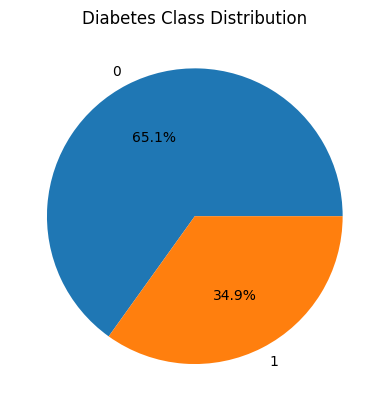

In [13]:
count.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title("Diabetes Class Distribution")

plt.show()


(array([ 17.,  35.,  77.,  84.,  97., 110., 113.,  80.,  61.,  30.,  29.,
         19.,   7.,   3.,   2.,   2.,   1.,   0.,   0.,   1.]),
 array([18.2  , 20.645, 23.09 , 25.535, 27.98 , 30.425, 32.87 , 35.315,
        37.76 , 40.205, 42.65 , 45.095, 47.54 , 49.985, 52.43 , 54.875,
        57.32 , 59.765, 62.21 , 64.655, 67.1  ]),
 <BarContainer object of 20 artists>)

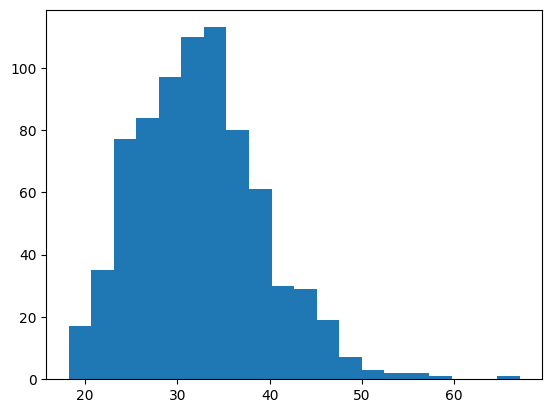

In [14]:
plt.hist(x=data["BMI"],bins=20)

<Axes: xlabel='Age', ylabel='BMI'>

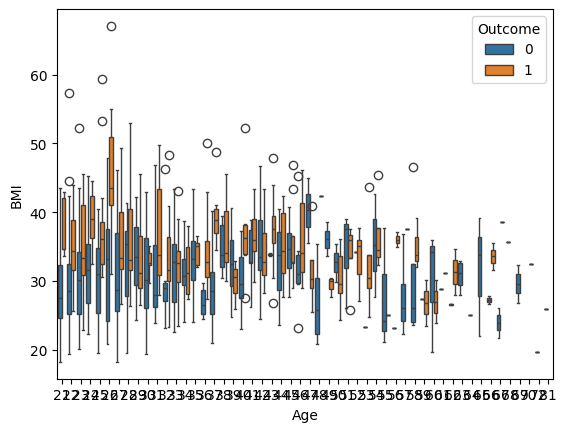

In [15]:
sns.boxplot(x="Age",y="BMI",data=data,hue=data["Outcome"])

<Axes: xlabel='Age', ylabel='BMI'>

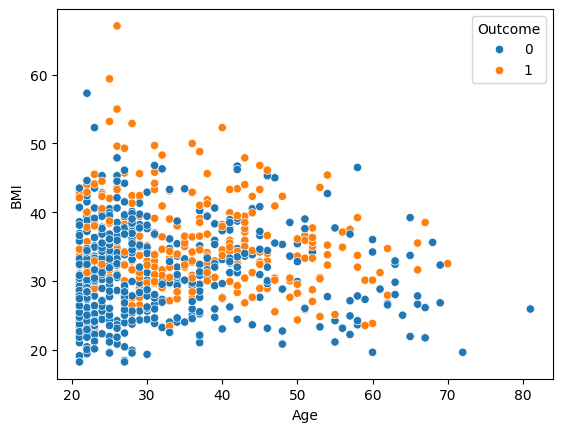

In [16]:
sns.scatterplot(x="Age", y="BMI", hue="Outcome", data=data)


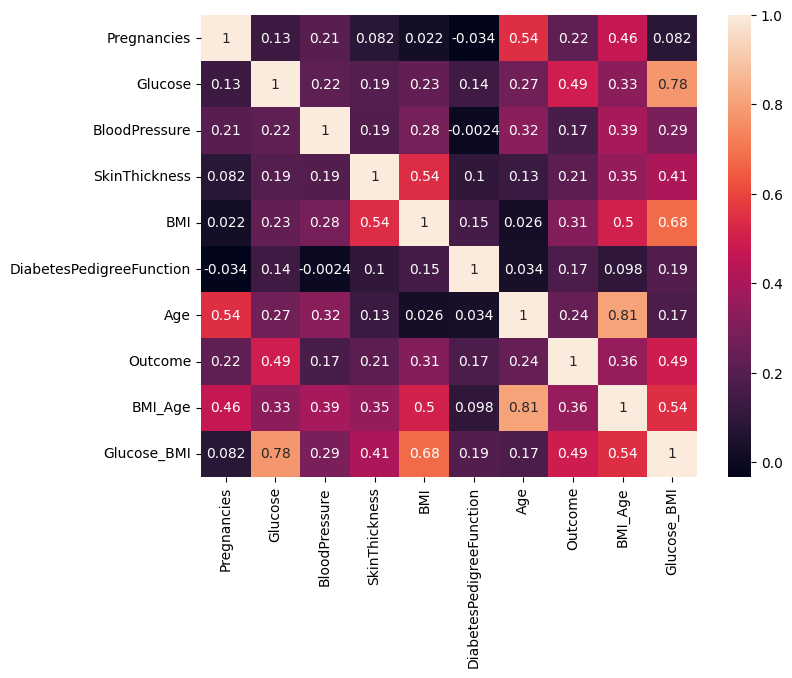

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True)
plt.show()

In [18]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age,Glucose_BMI
0,6,148.0,72.0,35.0,33.6,0.627,50,1,1680.0,4972.8
1,1,85.0,66.0,29.0,26.6,0.351,31,0,824.6,2261.0
2,8,183.0,64.0,29.0,23.3,0.672,32,1,745.6,4263.9
3,1,89.0,66.0,23.0,28.1,0.167,21,0,590.1,2500.9
4,0,137.0,40.0,35.0,43.1,2.288,33,1,1422.3,5904.7
...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,32.9,0.171,63,0,2072.7,3322.9
764,2,122.0,70.0,27.0,36.8,0.340,27,0,993.6,4489.6
765,5,121.0,72.0,23.0,26.2,0.245,30,0,786.0,3170.2
766,1,126.0,60.0,29.0,30.1,0.349,47,1,1414.7,3792.6


In [19]:
data["Outcome"].value_counts()  # check data outcome has imbalance data

Outcome
0    500
1    268
Name: count, dtype: int64

after choose best model and testing  so we save  our  clean data

In [67]:
data.to_csv("diabetes_clean.csv", index=False)

In [20]:
x = data.drop("Outcome", axis=1)   # remove target
y = data["Outcome"]               # target only


In [21]:

print(x.dtypes)


Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
BMI_Age                     float64
Glucose_BMI                 float64
dtype: object


In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=43)

In [23]:
sampling=SMOTE(random_state=45)
x_sampling,y_sampling=sampling.fit_resample(x_train,y_train)


In [24]:
y_sampling.value_counts()

Outcome
0    376
1    376
Name: count, dtype: int64

Here first we use Logistic regression

In [25]:
model_logis=LogisticRegression()
model_logis.fit(x_sampling,y_sampling)

c:\Users\Amit kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [26]:
y_pred_logis=model_logis.predict(x_test)
print(y_pred_logis)
print("Logistic regression testig score : ",model_logis.score(x_test,y_test))
print("Logistic regression trainig  score",model_logis.score(x_sampling,y_sampling))

[0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 1 1 0 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0
 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 1
 0 0 0 0 1 0 0 1 1 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0
 0 1 0 1 0 0 0 1 0 1 1 0 0 1 0 0 0 1 0 1 0 0 1 1 1 1 0 0 1 0 0 0 0 0 0 1 0
 1 1 1 1 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 0 1 0
 1 1 1 1 0 1 0]
Logistic regression testig score :  0.765625
Logistic regression trainig  score 0.7473404255319149


second we use DecisionTreeClassifier to get better accuracy and recall

In [28]:
model_decision=DecisionTreeClassifier(max_depth=1)
model_decision.fit(x_sampling,y_sampling)

DecisionTreeClassifier(max_depth=1)

In [29]:
y_pred_decision=model_decision.predict(x_test)
print(y_pred_decision)
print("Decision tree  testing score : ",model_decision.score(x_test,y_test))
print("Decision tree training score : ",model_decision.score(x_sampling,y_sampling))

[0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 1 0 1 1 1 1 1 0 0 1 0 0 0 1 1
 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 0 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 1 0 1 0 0
 0 0 1 1 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 1 1 1 1 1 0 0 1 0 0 0 1 1 1 0 0 1 1 1 1 0 0 1 0 1 1 1 0 1 1 0
 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 0]
Decision tree  testing score :  0.6510416666666666
Decision tree training score :  0.6954787234042553


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

pred = model_logis.predict(x_test)

print("Logistic regression confusion metric score : \n" ,confusion_matrix(y_test, y_pred_logis))

print("Logistic regression classification report : \n",classification_report(y_test, y_pred_logis))

from sklearn.metrics import classification_report, confusion_matrix

pred = model_logis.predict(x_test)

print("Decision tree confusion metric score : \n" ,confusion_matrix(y_test, y_pred_decision))

print("Decision tree classification report : \n",classification_report(y_test, y_pred_decision))


Decision tree confusion metric score : 
 [[63 61]
 [ 6 62]]
Decision tree classification report : 
               precision    recall  f1-score   support

           0       0.91      0.51      0.65       124
           1       0.50      0.91      0.65        68

    accuracy                           0.65       192
   macro avg       0.71      0.71      0.65       192
weighted avg       0.77      0.65      0.65       192



In [31]:

model_svm=SVC()
model_svm.fit(x_sampling,y_sampling)

SVC()

In [32]:
y_pred_svm=model_svm.predict(x_test)
y_pred_decision
print("SVM testing score:",model_svm.score(x_test,y_test))
print("SVM trainig score",model_svm.score(x_sampling,y_sampling))

SVM testing score: 0.7395833333333334


SVM trainig score 0.7154255319148937


SVM confusion metric score : 
 [[94 30]
 [20 48]]
SVM classification report : 
               precision    recall  f1-score   support

           0       0.82      0.76      0.79       124
           1       0.62      0.71      0.66        68

    accuracy                           0.74       192
   macro avg       0.72      0.73      0.72       192
weighted avg       0.75      0.74      0.74       192



In [34]:
model_random=RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    min_samples_split=10,
    random_state=45
)

model_random.fit(x_sampling,y_sampling)

RandomForestClassifier(max_depth=4, min_samples_split=10, n_estimators=200,
                       random_state=45)

In [35]:
y_pred_random=model_random.predict(x_test)
print(y_pred_random)
print("Random forest testing score : ",model_random.score(x_test,y_test))
print("Random forest trainig score",model_random.score(x_sampling,y_sampling))

[0 0 0 0 0 1 0 1 1 0 0 0 0 1 1 0 1 0 1 1 0 0 1 0 1 1 0 1 1 0 0 1 0 0 0 0 1
 1 1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0
 0 0 0 0 1 0 1 1 1 1 0 1 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 1 1
 1 1 0 1 0 0 0 1 0 1 1 0 0 1 0 0 0 1 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 0 0 1 0
 1 0 1 1 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 0 1 1
 1 0 1 0 0 0 0]
Random forest testing score :  0.8072916666666666
Random forest trainig score 0.836436170212766


In [56]:
model=AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=200,
        learning_rate=0.1,
        random_state=45
    )

In [59]:
kf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [60]:
score_adaboost=cross_validate(model,x,y,cv=kf,scoring=["recall", "accuracy"]
)

print("AdaBoost Recall:", score_adaboost["test_recall"].mean())
print("AdaBoost Accuracy:", score_adaboost["test_accuracy"].mean())

AdaBoost Recall: 0.5859538784067085
AdaBoost Accuracy: 0.7681860623037094


In [61]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=200,
    learning_rate=0.1,
    random_state=25
)

model.fit(x_sampling, y_sampling)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                   learning_rate=0.1, n_estimators=200, random_state=25)

In [65]:
y_pred_random=model.predict(x_test)
print("Adaboost testing score : ",model.score(x_test,y_test))
print("Adaboost trainig score",model.score(x_sampling,y_sampling))

Adaboost testing score :  0.8020833333333334
Adaboost trainig score 0.8125


In [64]:
from sklearn.metrics import classification_report, confusion_matrix
pred = model_logis.predict(x_test)
print("Logistic regression confusion metric score : \n" ,confusion_matrix(y_test, y_pred_logis))
print("Logistic regression classification report : \n",classification_report(y_test, y_pred_logis))


from sklearn.metrics import classification_report, confusion_matrix
pred = model_logis.predict(x_test)
print("Decision tree confusion metric score : \n" ,confusion_matrix(y_test, y_pred_decision))
print("Decision tree classification report : \n",classification_report(y_test, y_pred_decision))


from sklearn.metrics import classification_report, confusion_matrix
pred = model_logis.predict(x_test)
print("SVM confusion metric score : \n" ,confusion_matrix(y_test, y_pred_svm))
print("SVM classification report : \n",classification_report(y_test, y_pred_svm))


from sklearn.metrics import classification_report, confusion_matrix
pred = model_logis.predict(x_test)
print("Random forest confusion metric score : \n" ,confusion_matrix(y_test, y_pred_random))
print("Random forest classification report : \n",classification_report(y_test, y_pred_random))



from sklearn.metrics import classification_report, confusion_matrix
pred = model.predict(x_test)
print("Adaboost confusion metric score : \n" ,confusion_matrix(y_test, y_pred_random))
print("Adaboost classification report : \n",classification_report(y_test, y_pred_random))


Logistic regression confusion metric score : 
 [[101  23]
 [ 22  46]]
Logistic regression classification report : 
               precision    recall  f1-score   support

           0       0.82      0.81      0.82       124
           1       0.67      0.68      0.67        68

    accuracy                           0.77       192
   macro avg       0.74      0.75      0.74       192
weighted avg       0.77      0.77      0.77       192

Decision tree confusion metric score : 
 [[63 61]
 [ 6 62]]
Decision tree classification report : 
               precision    recall  f1-score   support

           0       0.91      0.51      0.65       124
           1       0.50      0.91      0.65        68

    accuracy                           0.65       192
   macro avg       0.71      0.71      0.65       192
weighted avg       0.77      0.65      0.65       192

SVM confusion metric score : 
 [[94 30]
 [20 48]]
SVM classification report : 
               precision    recall  f1-score   supp